# Downloading and plotting Copernicus data with Python

First, create a virtual environment: 
`conda create --name bioc26` 

and activate it:
`conda activate bioc26`

Within this virtual environment, we can now install the libraries needed:
`conda install matplotlib xarray netCDF4 numpy pandas cartopy jupyter copernicusmarine`

To deactivate the virtual environment (e.g., end of the day), do `conda deactivate`. 


When selecting the kernel in VS code, make sure to select 'bioc26'. 

In the reminal, run `copernicusmarine login` to store your login credentials, which is needed later for the data download.

## Loading libraries and data

In [56]:

# load libraries

from datetime import timedelta as delta
from glob import glob

import matplotlib.pyplot as plt
import xarray as xr

import netCDF4 as nc
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# some plotting helpers
land = cfeature.NaturalEarthFeature('physical', 'land', \
    scale='50m', edgecolor='k', facecolor=cfeature.COLORS['land'])
# ocean = cfeature.NaturalEarthFeature('physical', 'ocean', \
#     scale='50m', edgecolor='w', facecolor=cfeature.COLORS['water'])

In [57]:
# create data directory
import os

os.makedirs('data', exist_ok=True)

## Downloading Copernicus data

Additional to using the Copernicus website, you can also download data programmatically using the copernicusmarine API. 
Via the website, you can also create the python command based on your pre selection of data and paste it below. 
In this example, we download a Level 3 data product of total and plankton functional type (PFT) chlorophyll concentrations. 

In [58]:
# load physical data

import copernicusmarine

# for this to work, install copernicusmarine toolbox first (either with pip or conda) and run `copernicusmarine login` 
# in the terminal to store your login credentials

#dsname = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
dsname = "cmems_obs-oc_bal_bgc-plankton_nrt_l3-olci-300m_P1D"

# if data with dsname does not exist on your drive, download it (takes long, large file)
if not glob(f"data/{dsname}.nc"):
  copernicusmarine.subset(
  dataset_id="cmems_obs-oc_bal_bgc-plankton_nrt_l3-olci-300m_P1D",
    variables=["CHL", "CRYPTO", "CYANOBLOOM", "DIATO", "DINO", "GREEN", "MICRO", "NANO", "PICO", "PROKAR", "QI_CHL", "SENSORMASK"],
    minimum_longitude=9,
    maximum_longitude=11,
    minimum_latitude=54,
    maximum_latitude=55.5,
    start_datetime="2026-06-04T00:00:00",
    end_datetime="2026-06-17T00:00:00",
    disable_progress_bar=False,
    output_filename = f"{dsname}.nc",
    output_directory = "data"
)




In [59]:
# load data (into your workspace)

chl_ds = xr.open_dataset(f"data/{dsname}.nc")

In [60]:
# inspect: 

chl_ds

<xarray.Dataset> Size: 133MB
Dimensions:     (time: 14, latitude: 557, longitude: 329)
Coordinates:
  * time        (time) datetime64[ns] 112B 2026-06-04 2026-06-05 ... 2026-06-17
  * latitude    (latitude) float32 2kB 54.0 54.0 54.01 54.01 ... 55.49 55.5 55.5
  * longitude   (longitude) float32 1kB 9.253 9.258 9.263 ... 10.99 10.99 11.0
Data variables:
    CHL         (time, latitude, longitude) float32 10MB ...
    CRYPTO      (time, latitude, longitude) float32 10MB ...
    CYANOBLOOM  (time, latitude, longitude) float32 10MB ...
    DIATO       (time, latitude, longitude) float32 10MB ...
    DINO        (time, latitude, longitude) float32 10MB ...
    GREEN       (time, latitude, longitude) float32 10MB ...
    MICRO       (time, latitude, longitude) float32 10MB ...
    NANO        (time, latitude, longitude) float32 10MB ...
    PICO        (time, latitude, longitude) float32 10MB ...
    PROKAR      (time, latitude, longitude) float32 10MB ...
    QI_CHL      (time, latitude, longitude) float32 10MB ...
    SENSORMASK  (time, latitude, longitude) float64 21MB ...
Attributes: (12/35)
    BALMLP_code_version:       BAL MLP ENSEMBLE 202411
    Conventions:               CF-1.4
    area:                      bal
    cmems_product_id:          OCEANCOLOUR_BAL_BGC_L3_NRT_009_131
    cmems_production_unit:     OC-CNR-ROMA-IT
    contact:                   technical@gos.artov.isac.cnr.it
    ...                        ...
    start_date:                2024-11-20
    stop_date:                 2024-11-20
    timeliness:                NR
    title:                     cmems_obs-oc_bal_bgc-plankton_nrt_l3-olci-300m...
    westernmost_longitude:     9.25
    copernicusmarine_version:  2.4.1

In [61]:
# look at CHL variable: (first time step, all lat and lon)

chl_ds.CHL[13,:,:]

<xarray.DataArray 'CHL' (latitude: 557, longitude: 329)> Size: 733kB
[183253 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 2kB 54.0 54.0 54.01 54.01 ... 55.49 55.5 55.5
  * longitude  (longitude) float32 1kB 9.253 9.258 9.263 ... 10.99 10.99 11.0
    time       datetime64[ns] 8B 2026-06-17
Attributes:
    comment:        Brando VE, Sammartino M, Colella S, Bracaglia M, Di Cicco...
    long_name:      Chlorophyll a concentration
    source:         OLCI - POLYMER v.4.14 Atmospheric Correction Processor - ...
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    type:           surface
    units:          milligram m^-3
    valid_max:      300.0
    valid_min:      0.01

Cartopy is a powerful tool for creating beautiful maps in earth system scuiscience using python. 
More information and documentation can be found here: https://cartopy.readthedocs.io/stable/



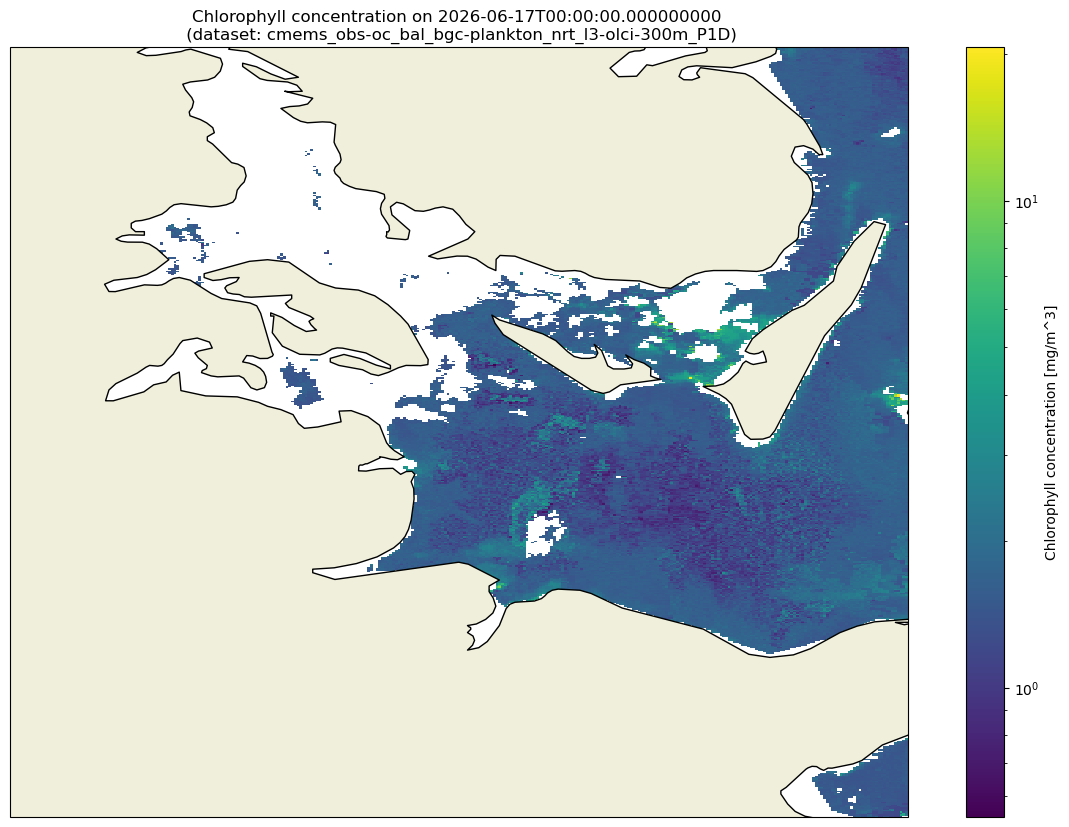

In [62]:
## create our first map of total chlorophyll:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colors

# some plotting helpers
land = cfeature.NaturalEarthFeature('physical', 'land', \
    scale='10m', edgecolor='k', facecolor=cfeature.COLORS['land'])


fig = plt.figure(figsize=(15, 10))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(land)

plt.pcolormesh(chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.CHL[13,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=colors.LogNorm()) # log-normalise color scale

plt.title(f"Chlorophyll concentration on {chl_ds.time[13].values} \n (dataset: {dsname})")

plt.colorbar(label='Chlorophyll concentration [mg/m^3]')
plt.show()

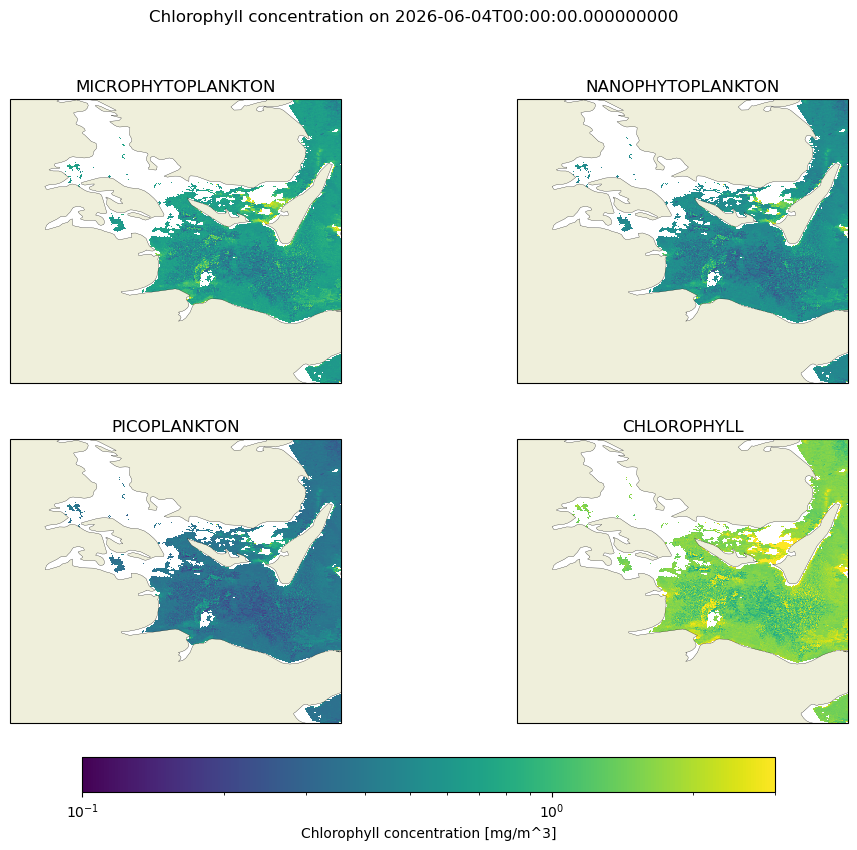

In [63]:
# plot PFT chlorophyll for selected groups: 


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})

fig.suptitle(f"Chlorophyll concentration on {chl_ds.time[0].values}")

# log-normalise color scale; apply to all colormesh calls to ensure same colorbar scale
norm = colors.LogNorm(vmin = 0.1, vmax = 3) 


m = axs[0,0].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.MICRO[13,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[0,0].add_feature(land, linewidth=0.2)
axs[0,0].set_title("MICROPHYTOPLANKTON")

axs[0,1].add_feature(land, linewidth=0.2)
axs[0,1].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.NANO[13,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[0,1].set_title("NANOPHYTOPLANKTON")


axs[1,0].add_feature(land, linewidth=0.2)
axs[1,0].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.PICO[13,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[1,0].set_title("PICOPLANKTON")

axs[1,1].add_feature(land, linewidth=0.2)
axs[1,1].pcolormesh(
               chl_ds.longitude, 
               chl_ds.latitude, 
               chl_ds.CHL[13,:,:], # select first time step here
               transform=ccrs.PlateCarree(), 
               cmap='viridis',
               norm=norm) # log-normalise color scale
axs[1,1].set_title("CHLOROPHYLL")

fig.colorbar( # add a colorbar
    m,
    ax=axs,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05,
    label='Chlorophyll concentration [mg/m^3]'
)

plt.show()



In [66]:
## extracting data for a specific location and time series plot:

#54.435	10.193 e.g. Strande
#54.498	10.144 e.g. Stollar Rinne
#54.530	10.040 e.g. Boknis Eck
#54.673	10.129 e.g. Schleimünde
#54.741	10.060 e.g. Geltinger Birk
#54.813	9.914 e.g. Felnsburg6
#54.894	9.793 e.g. Felnsburg7
#54.886	9.606 e.g. Felnsburg8
#54.840	9.501 e.g. Felnsburg9

lh_lat = 54.741
lh_lon = 10.060

# e.g. Kiel Leuchtturm: 54.499199, 10.274029
# lh_lat = 54.499199
# lh_lon = 10.274029

point = chl_ds.sel(latitude=lh_lat, longitude=lh_lon, method='nearest')
point


<xarray.Dataset> Size: 848B
Dimensions:     (time: 14)
Coordinates:
  * time        (time) datetime64[ns] 112B 2026-06-04 2026-06-05 ... 2026-06-17
    latitude    float32 4B 54.74
    longitude   float32 4B 10.06
Data variables:
    CHL         (time) float32 56B ...
    CRYPTO      (time) float32 56B ...
    CYANOBLOOM  (time) float32 56B ...
    DIATO       (time) float32 56B ...
    DINO        (time) float32 56B ...
    GREEN       (time) float32 56B ...
    MICRO       (time) float32 56B ...
    NANO        (time) float32 56B ...
    PICO        (time) float32 56B ...
    PROKAR      (time) float32 56B ...
    QI_CHL      (time) float32 56B ...
    SENSORMASK  (time) float64 112B ...
Attributes: (12/35)
    BALMLP_code_version:       BAL MLP ENSEMBLE 202411
    Conventions:               CF-1.4
    area:                      bal
    cmems_product_id:          OCEANCOLOUR_BAL_BGC_L3_NRT_009_131
    cmems_production_unit:     OC-CNR-ROMA-IT
    contact:                   technical@gos.artov.isac.cnr.it
    ...                        ...
    start_date:                2024-11-20
    stop_date:                 2024-11-20
    timeliness:                NR
    title:                     cmems_obs-oc_bal_bgc-plankton_nrt_l3-olci-300m...
    westernmost_longitude:     9.25
    copernicusmarine_version:  2.4.1

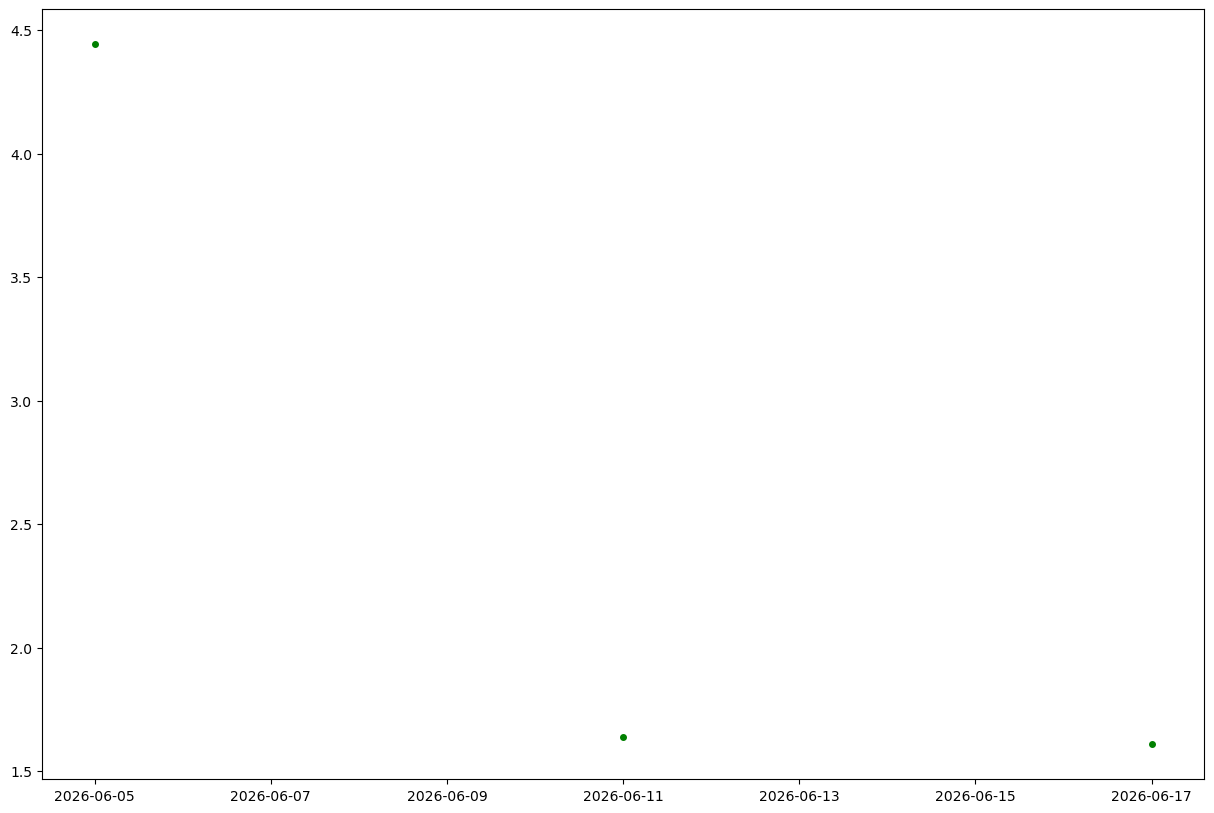

In [67]:
# easy scatter plot of total chlorophyll at this location over time:

fig = plt.figure(figsize=(15, 10))

# plt.scatter(point.time, point.CHL, color='green', label='Total chlorophyll')
plt.plot(point.time, point.CHL, color='green', label='Total chlorophyll',
          linewidth=2, marker='o', markersize=4)
